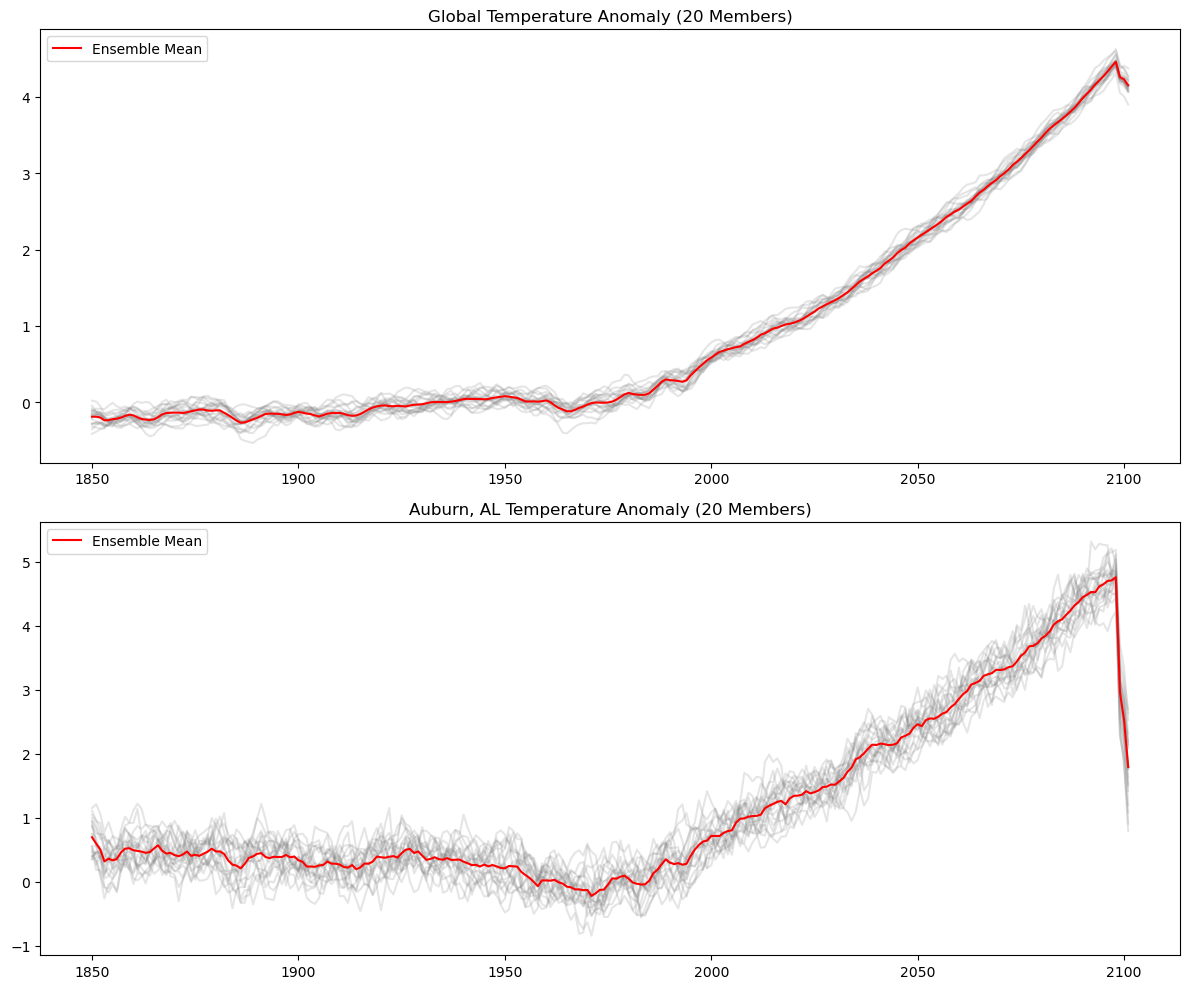

In [1]:
import os, glob, numpy as np, xarray as xr, matplotlib.pyplot as plt

TREFHT_DIR = "/glade/campaign/collections/gdex/data/d651056/CESM2-LE/atm/proc/tseries/month_1/TREFHT"

GISS_PATH = "/glade/work/kumar34/GSEI2070_DAT/gistemp1200_GHCNv4_ERSSTv5.nc"

MEMBERS = [
    "LE2-1001.001", "LE2-1021.002", "LE2-1041.003", "LE2-1061.004", "LE2-1081.005",
    "LE2-1101.006", "LE2-1121.007", "LE2-1141.008", "LE2-1161.009", "LE2-1181.010",
    "LE2-1301.011", "LE2-1301.012", "LE2-1301.013", "LE2-1301.014", "LE2-1301.015",
    "LE2-1301.016", "LE2-1301.017", "LE2-1301.018", "LE2-1301.019", "LE2-1301.020"
]

def load_mem(m):
    f = sorted(glob.glob(os.path.join(TREFHT_DIR, f"*.{m}.*.nc")))
    return xr.open_mfdataset(f, combine="nested", concat_dim="time").expand_dims({"ensemble":[m]})

ds = xr.concat([load_mem(m) for m in MEMBERS], dim="ensemble")
trefht = ds["TREFHT"]

climo = trefht.sel(time=slice("1951-01-01", "1980-12-31")).mean(dim=["time", "ensemble"])
ann_anom = (trefht.groupby("time.year").mean("time") - climo).compute()

w = np.cos(np.deg2rad(ann_anom.lat))
glb_anom = ann_anom.weighted(w).mean(dim=["lat", "lon"])

aub_anom = ann_anom.sel(lat=32.61, lon=274.52, method="nearest")

try:
    giss = xr.open_dataset(GISS_PATH)["tempanomaly"].rename({"tempanomaly":"t"}).groupby("time.year").mean("time")
    giss_glb = giss.weighted(w).mean(dim=["lat", "lon"]).compute()
except: giss_glb = None

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

for a, data, title in zip(ax, [glb_anom, aub_anom], ["Global", "Auburn, AL"]):
    for m in MEMBERS:
        a.plot(data.year, data.sel(ensemble=m).rolling(year=5, center=True, min_periods=1).mean(), color="gray", alpha=0.2)
    a.plot(data.year, data.mean("ensemble").rolling(year=5, center=True, min_periods=1).mean(), color="red", label="Ensemble Mean")
    if title == "Global" and giss_glb is not None:
        a.plot(giss_glb.year, giss_glb.rolling(year=5, center=True, min_periods=1).mean(), color="black", label="GISS Obs")
    a.set_title(f"{title} Temperature Anomaly (20 Members)")
    a.legend()

plt.tight_layout()
plt.show()